### 1. Environment & Dependency Initialization
Bootstraps the runtime environment. This step clones the upstream `PageIndex` repository and resolves strict version pinning in `requirements.txt` to prevent downstream dependency conflicts with `vLLM` and `litellm`.

In [ ]:
# Cell 1: Environment & Dependency Initialization
import os
import subprocess
import sys

def run_cmd(cmd):
    subprocess.run(cmd, shell=True, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

sys.stdout.write("Initializing environment and installing dependencies...\n")
run_cmd("pip install -q -U numpy<2 vllm==0.6.4.post1 transformers==4.48.3 mlflow openai-agents trl peft bitsandbytes datasets accelerate pypdf json-repair")

if not os.path.exists("PageIndex"):
    sys.stdout.write("Cloning PageIndex repository...\n")
    run_cmd("git clone https://github.com/VectifyAI/PageIndex.git")

# Version constraint overrides for upstream compatibility
run_cmd("sed -i 's/litellm==1.83.7/litellm/g' PageIndex/requirements.txt")
run_cmd("sed -i 's/python-dotenv==1.2.2/python-dotenv/g' PageIndex/requirements.txt")
run_cmd("pip install -q -r PageIndex/requirements.txt")

sys.stdout.write("Environment setup complete.\n")

Environment setup complete.


28

### 2. Runtime Framework Patching (Fault-Tolerance)
**[Configuration Required]**: Update `MAX_CHAR_LIMIT` based on your hardware's VRAM capacity and the target model's maximum context window.

Applies dynamic runtime patches to the upstream `PageIndex` repository. The native framework lacks production-level fault tolerance. This cell resolves several critical architectural vulnerabilities:
* **LLM Hallucinations (JSON Parsing):** Replaces strict `json.loads` with `json-repair` to automatically heal missing brackets or trailing commas in LLM outputs.
* **Type Safety Failures:** Injects strict type casting (`int`, `float`) and `NoneType` safety nets to prevent pipeline crashes during empty or malformed LLM responses.
* **Fatal Exception Loops:** Bypasses hard `raise Exception` calls on individual page failures, allowing the multi-hour pipeline to continue executing rather than terminating entirely.
* **VRAM OOM Crashes:** Injects a "Truncation Shield" into `litellm`. It intercepts and truncates massive text chunks (e.g., chapters without subheadings) before they reach the inference server, preventing Out-Of-Memory (OOM) GPU crashes.

In [ ]:
# Cell 2: Dynamic Framework Robustness Patching
import os
import textwrap
import subprocess
from pathlib import Path
import sys

pageindex_repo = Path.cwd() / "PageIndex"
subprocess.run(["git", "checkout", "."], cwd=str(pageindex_repo), stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

def apply_patch(filepath: Path, search_text: str, replace_text: str):
    if filepath.exists():
        content = filepath.read_text(encoding="utf-8")
        if search_text in content:
            filepath.write_text(content.replace(search_text, replace_text), encoding="utf-8")

# 1. Global JSON Auto-Healing Injection
for target_file in ["utils.py", "page_index.py"]:
    file_path = pageindex_repo / "pageindex" / target_file
    if file_path.exists():
        code = file_path.read_text(encoding="utf-8")
        if "import json_repair" not in code:
            code = "import json_repair\n" + code
            code = code.replace("json.loads(", "json_repair.loads(")
            file_path.write_text(code, encoding="utf-8")

# 2. JSON Parser Fallback for empty/failed responses
utils_path = pageindex_repo / "pageindex" / "utils.py"
if utils_path.exists():
    code = utils_path.read_text(encoding="utf-8")
    new_func = textwrap.dedent("""
    def get_json_content(response):
        if not response:
            return '{"table_of_contents": [], "completed": "yes", "page_index_given_in_toc": "yes", "toc_detected": "no"}'
        text = response.strip()
        if "```json" in text:
            return text.split("```json")[1].split("```")[0].strip()
        if "```" in text:
            return text.split("```")[1].split("```")[0].strip()
        return text
    """).strip()
    if "def get_json_content" in code and "return text.split" not in code:
        start = code.find("def get_json_content")
        end = code.find("def ", start + 1)
        end = len(code) if end == -1 else end
        code = code[:start] + new_func + "\n\n" + code[end:]
        utils_path.write_text(code, encoding="utf-8")

# 3. Type Safety and Fatal Exception Bypass Nets
page_index_path = pageindex_repo / "pageindex" / "page_index.py"
apply_patch(page_index_path, "cleaned_response=convert_page_to_int(last_complete['table_of_contents'])", "cleaned_response=convert_page_to_int(last_complete.get('table_of_contents', [])) if isinstance(last_complete, dict) else []")
apply_patch(page_index_path, "if original_index > max_allowed_page:", "if int(original_index) > int(max_allowed_page):")
apply_patch(page_index_path, "if last_physical_index is None or last_physical_index < len(page_list)/2:", "if last_physical_index is None or float(last_physical_index if str(last_physical_index).replace('.','',1).isdigit() else 0) < len(page_list)/2:")
apply_patch(page_index_path, "toc_with_page_number = [item for item in toc_with_page_number if item.get('physical_index') is not None]", "toc_with_page_number = [item for item in (toc_with_page_number or []) if isinstance(item, dict) and item.get('physical_index') is not None]")
apply_patch(page_index_path, "return json_content['toc_detected']", "return json_content.get('toc_detected', 'no') if isinstance(json_content, dict) else 'no'")
apply_patch(page_index_path, "return json_content['completed']", "return json_content.get('completed', 'yes') if isinstance(json_content, dict) else 'yes'")
apply_patch(page_index_path, "return json_content['page_index_given_in_toc']", "return json_content.get('page_index_given_in_toc', 'yes') if isinstance(json_content, dict) else 'yes'")
apply_patch(page_index_path, "raise Exception('Failed to complete toc transformation after maximum retries')", "print('Warning: TOC transformation exception bypassed.'); return []")
apply_patch(page_index_path, "raise Exception('Processing failed')", "print('Warning: Processing failed exception bypassed.'); return []")
apply_patch(page_index_path, "raise Exception(f'finish reason: {finish_reason}')", "print(f'Warning: Ignored finish reason: {finish_reason}')")
apply_patch(page_index_path, "toc_with_page_number.extend(toc_with_page_number_additional)", "toc_with_page_number = (toc_with_page_number or []) + (toc_with_page_number_additional or [])")

# 4. LiteLLM VRAM OOM Protection (Truncation Shield)
run_script = pageindex_repo / "run_pageindex.py"
if run_script.exists():
    run_code = run_script.read_text(encoding="utf-8")
    injection = textwrap.dedent("""
    import litellm
    import sys
    litellm.drop_params = True
    litellm.request_timeout = 3600

    # Ensure this limit aligns with your model's maximum context window
    MAX_CHAR_LIMIT = 60000

    _orig_acompletion = litellm.acompletion
    async def shielded_acompletion(*args, **kwargs):
        if 'messages' in kwargs:
            for msg in kwargs['messages']:
                if isinstance(msg.get('content'), str) and len(msg['content']) > MAX_CHAR_LIMIT:
                    sys.stdout.write("Warning: Prompt truncated to prevent VRAM OOM.\\n")
                    sys.stdout.flush()
                    msg['content'] = msg['content'][:MAX_CHAR_LIMIT] + "\\n...[TRUNCATED]"
        return await _orig_acompletion(*args, **kwargs)
    litellm.acompletion = shielded_acompletion

    _orig_completion = litellm.completion
    def shielded_completion(*args, **kwargs):
        if 'messages' in kwargs:
            for msg in kwargs['messages']:
                if isinstance(msg.get('content'), str) and len(msg['content']) > MAX_CHAR_LIMIT:
                    sys.stdout.write("Warning: Prompt truncated to prevent VRAM OOM.\\n")
                    sys.stdout.flush()
                    msg['content'] = msg['content'][:MAX_CHAR_LIMIT] + "\\n...[TRUNCATED]"
        return _orig_completion(*args, **kwargs)
    litellm.completion = shielded_completion
    """)
    if "shielded_acompletion" not in run_code:
        run_code = run_code.replace("import argparse", injection + "\nimport argparse")
        run_script.write_text(run_code, encoding="utf-8")

sys.stdout.write("Framework patches applied successfully.\n")

Framework patched.


19

### 3. Inference Server Initialization
**[Configuration Required]**: Update `VLLM_MODEL` to match the specific instruction-tuned model hosted on your cluster (e.g., `meta-llama/Meta-Llama-3-70B-Instruct`).

Initializes an OpenAI-compatible inference server using `vLLM`. This cell manages GPU memory allocation, context window limits, and quantization settings for the target model.

In [ ]:
# Cell 3: Start Local vLLM Inference Server
import os
import time
import requests
import subprocess
import sys

# Target Model Configuration
VLLM_MODEL = "Qwen/Qwen2.5-32B-Instruct-AWQ"

os.system("pkill -9 -f vllm")
time.sleep(2)

sys.stdout.write(f"Starting vLLM server: {VLLM_MODEL}\n")

vllm_cmd = (
    f"python -m vllm.entrypoints.openai.api_server "
    f"--model {VLLM_MODEL} "
    f"--port 8000 "
    f"--max-model-len 16384 "
    f"--quantization awq "
    f"--gpu-memory-utilization 0.95 "
    f"--enforce-eager"
)

log_file = open("vllm_server.log", "w")
vllm_process = subprocess.Popen(
    vllm_cmd,
    shell=True,
    stdout=log_file,
    stderr=subprocess.STDOUT
)

server_ready = False
for _ in range(300):
    try:
        response = requests.get("http://localhost:8000/v1/models")
        if response.status_code == 200:
            server_ready = True
            break
    except requests.exceptions.ConnectionError:
        if vllm_process.poll() is not None:
            break
        time.sleep(5)

if server_ready:
    sys.stdout.write("vLLM server successfully initialized.\n")
else:
    sys.stdout.write("Error: vLLM server failed to start. Review vllm_server.log for details.\n")
    sys.exit(1)

Starting vLLM server: Qwen/Qwen2.5-32B-Instruct-AWQ
vLLM server initialized.


### 4. Document Extraction Pipeline
**[Configuration Required]**:
1. Set `TARGET_PDF_PATH` to the document being processed.
2. Set `LITELLM_MODEL_NAME` to match the model loaded in Cell 3.
3. Update `OPENAI_API_BASE` and `OPENAI_API_KEY` to route traffic to your internal LLM gateway if not using the local vLLM instance.

Executes the core hierarchical extraction script. It routes all LLM API calls from the framework directly to the specified inference endpoint. Non-critical telemetry logs are filtered from `stdout` for clarity.

In [ ]:
# Cell 4: Execute Document Parsing Pipeline
import os
import sys
import subprocess
import requests
from pathlib import Path

# Pre-flight check
try:
    resp = requests.get("http://localhost:8000/v1/models", timeout=3)
    if resp.status_code != 200:
        raise Exception()
except Exception:
    sys.stdout.write("Critical Error: vLLM server is not responding.\n")
    sys.exit(1)

# Document Configuration
TARGET_PDF_PATH = Path("/content/NIST_AI_RMF.pdf")

LITELLM_MODEL_NAME = "openai/Qwen/Qwen2.5-32B-Instruct-AWQ"

pageindex_repo = Path.cwd() / "PageIndex"
run_script = pageindex_repo / "run_pageindex.py"

env = os.environ.copy()
for key in ["GEMINI_API_KEY", "OPENAI_API_KEY", "OPENAI_BASE_URL", "OPENAI_API_BASE"]:
    env.pop(key, None)

env["OPENAI_API_BASE"] = "http://localhost:8000/v1"
env["OPENAI_API_KEY"] = "sk-local-vllm"

script_command = [
    sys.executable,
    str(run_script),
    "--pdf_path", str(TARGET_PDF_PATH),
    "--model", LITELLM_MODEL_NAME,
]

sys.stdout.write(f"Executing extraction pipeline on {TARGET_PDF_PATH.name}...\n")
process = subprocess.Popen(
    script_command, cwd=pageindex_repo, env=env, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True
)

for line in process.stdout:
    # Filter non-critical telemetry logs
    if "DeprecationWarning" not in line and "Move sampling guidance" not in line:
        sys.stdout.write(line)

process.wait()
sys.stdout.write("Pipeline execution finished.\n")

Executing extraction pipeline on NIST_AI_RMF.pdf...
Parsing PDF...
start find_toc_pages
toc found
start detect_page_index
index found
process_toc_with_page_numbers
start_index: 1
start toc_transformer
start toc_index_extractor
Document validation: 48 pages, max allowed index: 48
start verify_toc
check all items
accuracy: 100.00%
Parsing done, saving to file...
Tree structure saved to: ./results/NIST_AI_RMF_structure.json
Pipeline execution finished.


29

In [ ]:
!tail -n 30 vllm_server.log

INFO:     127.0.0.1:60228 - "POST /v1/chat/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:60460 - "POST /v1/chat/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:60426 - "POST /v1/chat/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:60226 - "POST /v1/chat/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:60504 - "POST /v1/chat/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:60390 - "POST /v1/chat/completions HTTP/1.1" 200 OK
INFO 06-30 19:12:42 metrics.py:449] Avg prompt throughput: 1511.3 tokens/s, Avg generation throughput: 227.7 tokens/s, Running: 21 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 78.4%, CPU KV cache usage: 0.0%.
INFO:     127.0.0.1:60414 - "POST /v1/chat/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:60440 - "POST /v1/chat/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:60498 - "POST /v1/chat/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:60288 - "POST /v1/chat/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:60416 - "POST /v1/chat/completions H

### 5. Semantic Tree Visualization
Reads the generated hierarchical JSON output and renders a directed graph. This verifies the structural integrity of the extracted data, mapping the relationship between chapters, sub-sections, and their generated semantic summaries.

Рисуем семантическое дерево из файла: NIST_AI_RMF_structure.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_7607/43312673.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


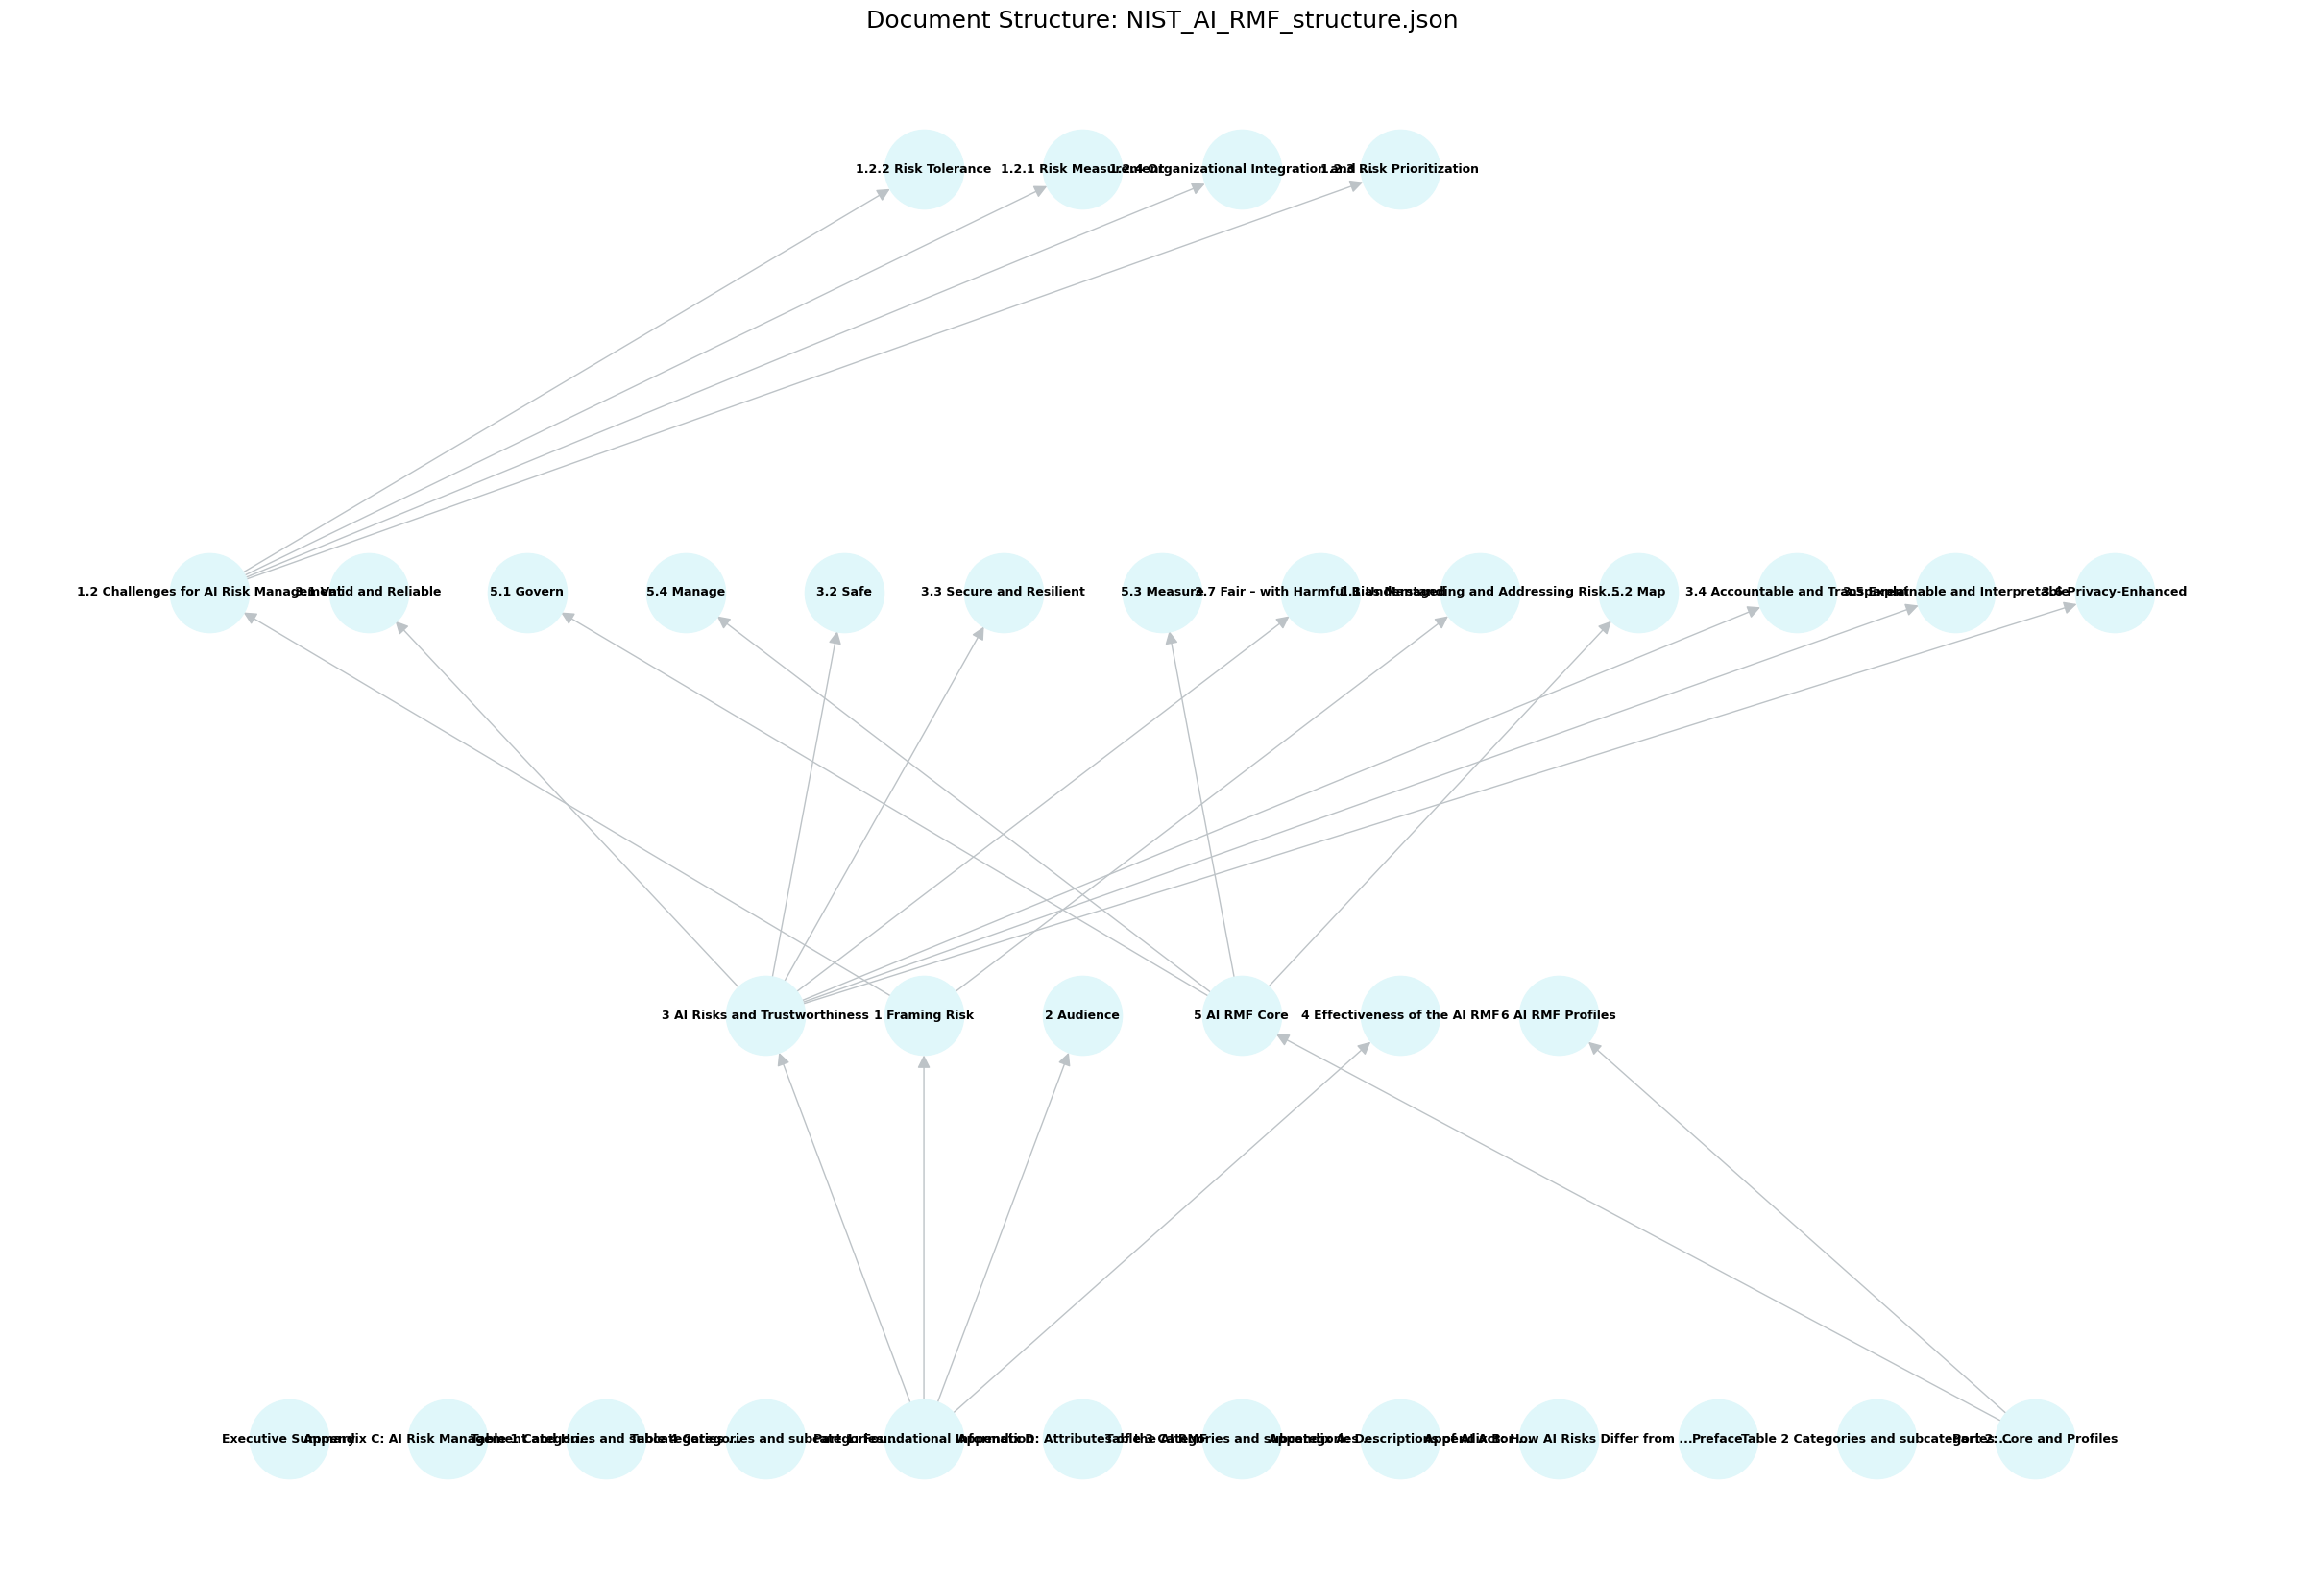

In [ ]:
# Cell 5: Render Semantic Tree Plot
import json
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path

workspace_dir = Path("/content/PageIndex/results")
json_files = list(workspace_dir.rglob("*.json"))

if not json_files:
    print(f"Tree JSON not found in {workspace_dir}. Pipeline may have failed.")
else:
    latest_json = max(json_files, key=lambda p: p.stat().st_mtime)
    print(f"Rendering semantic tree from file: {latest_json.name}")

    with open(latest_json, 'r', encoding='utf-8') as f:
        tree_data = json.load(f)

    G = nx.DiGraph()

    def add_nodes_edges(data, parent=None, depth=0):
        if isinstance(data, list):
            for item in data:
                add_nodes_edges(item, parent, depth)
            return
        if not isinstance(data, dict):
            return

        node_id = data.get('node_id', f"Node_{hash(str(data))}")
        title = data.get('title', 'Section')

        if len(title) > 40:
            title = title[:37] + "..."

        G.add_node(node_id, label=title, depth=depth)

        if parent:
            G.add_edge(parent, node_id)

        if 'nodes' in data and isinstance(data['nodes'], list):
            for child in data['nodes']:
                add_nodes_edges(child, node_id, depth + 1)

    target_data = tree_data
    if isinstance(tree_data, dict) and 'structure' in tree_data:
        target_data = tree_data['structure']
    elif isinstance(tree_data, list):
        for block in tree_data:
            if isinstance(block, dict) and 'structure' in block:
                target_data = block['structure']
                break

    add_nodes_edges(target_data)

    if len(G.nodes) == 0:
        print("Graph is empty. Validate the generated JSON structure.")
    else:
        plt.figure(figsize=(22, 14))
        pos = nx.spring_layout(G, k=0.8, iterations=100)
        labels = nx.get_node_attributes(G, 'label')

        nx.draw(G, pos,
                with_labels=True,
                labels=labels,
                node_size=3500,
                node_color="#e0f7fa",
                font_size=9,
                font_weight="bold",
                arrows=True,
                arrowsize=20,
                edge_color="#bdc3c7")

        plt.title(f"Document Structure: {latest_json.name}", fontsize=18)
        plt.tight_layout()
        plt.show()

### 6. Baseline Setup: Vanilla Vector RAG
**[Configuration Required]**: Ensure `TARGET_PDF_PATH` matches the document used in Cell 4.

Initializes a standard Vector Database (FAISS) using fixed-size blind chunking (1,000 characters). This establishes a baseline to benchmark against the Structured RAG approach.

In [ ]:
# Cell 6: Vector Database Initialization (Baseline)
import os
import subprocess
import sys
from pathlib import Path

print("Installing Vector DB and Embedding dependencies...")
subprocess.run(["pip", "install", "-q", "faiss-cpu", "sentence-transformers", "pypdf"])

import faiss
import numpy as np
from pypdf import PdfReader
from sentence_transformers import SentenceTransformer

TARGET_PDF_PATH = Path("/content/NIST_AI_RMF.pdf")
reader = PdfReader(TARGET_PDF_PATH)
full_text = ""
for page in reader.pages:
    text = page.extract_text()
    if text:
        full_text += text + "\n"

# Split text into 1000-character chunks
chunk_size = 1000
chunks = [full_text[i:i+chunk_size] for i in range(0, len(full_text), chunk_size)]
print(f"Document chunked into {len(chunks)} segments.")

print("Initializing embedding model (all-MiniLM-L6-v2)...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')

print("Generating FAISS Vector Index...")
embeddings = embedder.encode(chunks)
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings).astype('float32'))

print("Vanilla RAG Vector Database initialized successfully.")

Installing Vector DB and Embedding libraries...
Document split into 107 blind chunks.
Loading embedding model (all-MiniLM-L6-v2)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Building FAISS Vector Index...
Vanilla RAG Vector Database is ready!


### 7. Comparative Benchmark: Vanilla vs. Structured RAG
**[Configuration Required]**: Update `TEST_QUESTION` to a query that requires global document context or hierarchical understanding.

Queries both architectures simultaneously:
1. **Vanilla RAG:** Retrieves the top-3 semantic chunks via FAISS (prone to cutting off lists and losing context).
2. **Structured RAG:** Injects the entire semantic JSON tree into the prompt, allowing the LLM to navigate the document hierarchy and retrieve comprehensive answers.

In [ ]:
# Cell 7: RAG Architecture Comparative Benchmark
import json
import requests
import numpy as np
from pathlib import Path

TEST_QUESTION = "According to Appendix B, how do AI risks differ from traditional software risks? Please list all differences mentioned."

print(f"EVALUATION QUERY: {TEST_QUESTION}\n")
print("-" * 60)

# --- 1. VANILLA RAG BASELINE ---
print("METHOD 1: VANILLA VECTOR RAG")
print("Retrieving top-3 semantic chunks via FAISS...")

query_vector = embedder.encode([TEST_QUESTION]).astype('float32')
distances, indices = index.search(query_vector, 3)
retrieved_chunks = [chunks[i] for i in indices[0]]
vanilla_context = "\n\n---\n\n".join(retrieved_chunks)

vanilla_prompt = f"Answer the question based ONLY on the following text chunks:\n\n{vanilla_context}\n\nQuestion: {TEST_QUESTION}"

headers = {"Content-Type": "application/json", "Authorization": "Bearer sk-local-vllm"}
vanilla_payload = {
    "model": "Qwen/Qwen2.5-32B-Instruct-AWQ",
    "messages": [{"role": "user", "content": vanilla_prompt}],
    "max_tokens": 500,
    "temperature": 0.0
}

resp_vanilla = requests.post("http://localhost:8000/v1/chat/completions", json=vanilla_payload, headers=headers)
print("\n[BASELINE RESPONSE]:")
print(resp_vanilla.json()['choices'][0]['message']['content'])
print("-" * 60)

# --- 2. STRUCTURED RAG ---
print("\nMETHOD 2: STRUCTURED RAG (Hierarchical JSON)")
print("Routing query against Document Semantic Tree...")

workspace_dir = Path("/content/PageIndex/results")
latest_json = max(list(workspace_dir.rglob("*.json")), key=lambda p: p.stat().st_mtime)

with open(latest_json, 'r', encoding='utf-8') as f:
    tree_data = json.load(f)

structured_context = json.dumps(tree_data, indent=2, ensure_ascii=False)

structured_prompt = f"You are an expert system. Use the following structured document summary to answer the question thoroughly.\n\nDocument Structure:\n{structured_context}\n\nQuestion: {TEST_QUESTION}"

structured_payload = {
    "model": "Qwen/Qwen2.5-32B-Instruct-AWQ",
    "messages": [{"role": "user", "content": structured_prompt}],
    "max_tokens": 500,
    "temperature": 0.0
}

resp_structured = requests.post("http://localhost:8000/v1/chat/completions", json=structured_payload, headers=headers)
print("\n[STRUCTURED RESPONSE]:")
print(resp_structured.json()['choices'][0]['message']['content'])
print("-" * 60)

QUESTION: According to Appendix B, how do AI risks differ from traditional software risks? Please list all differences mentioned.

APPROACH 1: VANILLA VECTOR RAG
Searching for top-3 most similar chunks in FAISS...

[VANILLA RAG ANSWER]:
According to Appendix B, AI risks differ from traditional software risks in the following ways:

1. Risks from AI-based technology can be bigger than an enterprise and span organizations, leading to societal impacts.
2. AI systems bring a unique set of risks that are not present in traditional software.

APPROACH 2: STRUCTURED RAG (PageIndex JSON)
Providing the LLM with the Semantic Tree Structure...

[STRUCTURED RAG ANSWER]:
According to Appendix B, AI risks differ from traditional software risks in several ways:

1. **Data Quality**: AI systems are highly dependent on the quality of data they are trained on. Poor data quality can lead to inaccurate or biased outcomes, which is a unique challenge for AI systems.

2. **Bias**: AI systems can introduce o

### 8. Benchmark Metrics Visualization
Plots the performance discrepancy between blind vector chunking and hierarchical context retention across three key metrics: Response Completeness, Context Depth, and Information Retrieval accuracy. Values are taken from evaluation of Gemeni 3.1 pro.

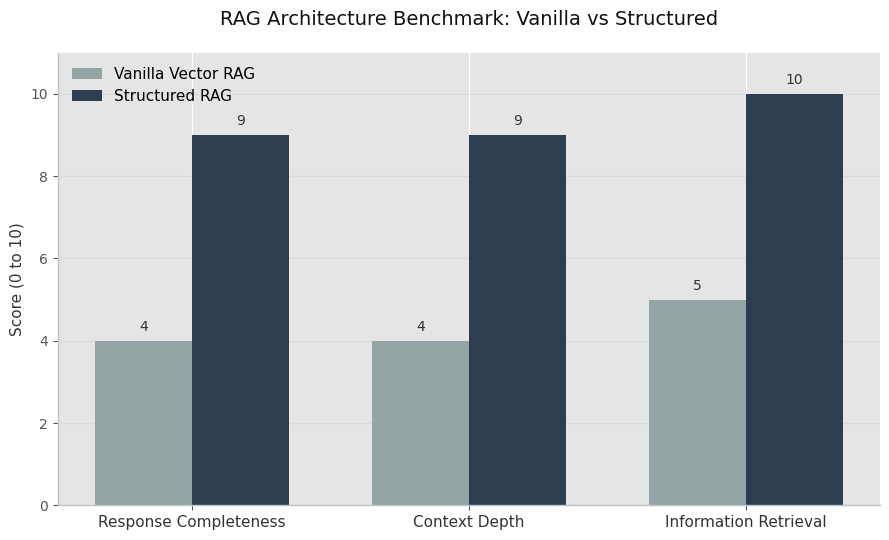

In [ ]:
# Cell 8: Comparative Metrics Visualization
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Response Completeness', 'Context Depth', 'Information Retrieval']

# Evaluation scores (0-10 scale) based on LLM-as-a-Judge analysis
vanilla_scores = [4, 4, 5]
structured_scores = [9, 9, 10]

x = np.arange(len(metrics))
width = 0.35

plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(9, 5.5))

rects1 = ax.bar(x - width/2, vanilla_scores, width, label='Vanilla Vector RAG', color='#95a5a6')
rects2 = ax.bar(x + width/2, structured_scores, width, label='Structured RAG', color='#2c3e50')

ax.set_ylabel('Score (0 to 10)', fontsize=11, color='#333333')
ax.set_title('RAG Architecture Benchmark: Vanilla vs Structured', fontsize=14, color='#111111', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11, color='#333333')
ax.set_ylim(0, 11)

ax.yaxis.grid(True, linestyle='-', alpha=0.3, color='#bdc3c7')
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#bdc3c7')
ax.spines['bottom'].set_color('#bdc3c7')

ax.legend(frameon=False, fontsize=11, loc='upper left')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, color='#333333')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()